In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import statsmodels.api as sm

#three different datasets from last 3 years

df = pd.read_csv(r'C:\Users\tilen\season-2324.csv')
df1 = pd.read_csv(r'C:\Users\tilen\season-2425.csv')
df2 = pd.read_csv(r'C:\Users\tilen\season-2526.csv')

#we merge them to one

df_bund = pd.concat([df, df1, df2], axis=0)

#we drop the columns we dont need

df_bund = df_bund.drop(columns= ['Referee', 'HY', 'AY', 'HF', 'AF', 'HR', 'AR'])
df_bund

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HC,AC
0,2023-08-18,Werder Bremen,Bayern Munich,0,4,A,0.0,1.0,A,6.0,25.0,1.0,10.0,0.0,6.0
1,2023-08-19,Augsburg,M'gladbach,4,4,D,3.0,3.0,D,20.0,9.0,8.0,6.0,8.0,7.0
2,2023-08-19,Hoffenheim,Freiburg,1,2,A,0.0,2.0,A,24.0,17.0,5.0,8.0,4.0,2.0
3,2023-08-19,Leverkusen,RB Leipzig,3,2,H,2.0,1.0,H,11.0,13.0,7.0,6.0,4.0,5.0
4,2023-08-19,Stuttgart,Bochum,5,0,H,2.0,0.0,H,19.0,4.0,9.0,1.0,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2026-05-16,Leverkusen,Hamburg,1,1,D,0.0,0.0,D,26.0,19.0,9.0,6.0,8.0,3.0
302,2026-05-16,M'gladbach,Hoffenheim,4,0,H,2.0,0.0,H,9.0,11.0,6.0,3.0,2.0,9.0
303,2026-05-16,St Pauli,Wolfsburg,1,3,A,0.0,1.0,A,11.0,19.0,2.0,10.0,8.0,9.0
304,2026-05-16,Union Berlin,Augsburg,4,0,H,2.0,0.0,H,17.0,11.0,9.0,1.0,4.0,9.0


In [3]:
#we compute the total goals scored from teams at home and away

home_goals = df_bund.groupby('HomeTeam')['FTHG'].sum()
away_goals = df_bund.groupby('AwayTeam')['FTAG'].sum()


stats1 = pd.DataFrame()


stats1['Home_Goals'] = home_goals
stats1['Away_Goals'] = away_goals

#we compute the total goals of the season

stats1['Total_Goals'] = stats1['Home_Goals'] + stats1['Away_Goals']

stats1 = stats1.reset_index().rename(columns={'HomeTeam': 'Team'})
stats1

,Team,Home_Goals,Away_Goals,Total_Goals
0,Augsburg,69,61,130
1,Bayern Munich,174,141,315
2,Bochum,42,33,75
3,Darmstadt,15,15,30
4,Dortmund,121,88,209
5,Ein Frankfurt,99,81,180
6,FC Koln,45,32,77
7,Freiburg,93,52,145
8,Hamburg,25,15,40
9,Heidenheim,66,62,128


In [4]:
#we will find now the total number of corners each team won
#we will follow the same patern as before with the goals
#first we compute the total number of corners won at home and away
#and after that we add these numbers in order to find the total number of corners won

Corners_stats = pd.DataFrame()

df_bund['HC'] = pd.to_numeric(df_bund['HC'], errors='coerce')
df_bund['AC'] = pd.to_numeric(df_bund['AC'], errors='coerce')

home = df_bund.groupby('HomeTeam')['HC'].sum().reset_index()
home.columns = ['Team', 'HomeCorners']

away = df_bund.groupby('AwayTeam')['AC'].sum().reset_index()
away.columns = ['Team', 'AwayCorners']

Corners_stats = pd.merge(home, away, on='Team', how='outer')

Corners_stats['TotalCorners'] = Corners_stats['HomeCorners'] + Corners_stats['AwayCorners']

Corners_stats

,Team,HomeCorners,AwayCorners,TotalCorners
0,Augsburg,266.0,211.0,477.0
1,Bayern Munich,367.0,296.0,663.0
2,Bochum,185.0,128.0,313.0
3,Darmstadt,64.0,51.0,115.0
4,Dortmund,334.0,214.0,548.0
5,Ein Frankfurt,280.0,208.0,488.0
6,FC Koln,195.0,150.0,345.0
7,Freiburg,225.0,175.0,400.0
8,Hamburg,64.0,61.0,125.0
9,Heidenheim,273.0,204.0,477.0


In [5]:
#we will find now the total number of half time goals each team scored
#and here again we follow the same steps as before with the corners and the goals

stats3 = pd.DataFrame()

df_bund['HTHG'] = pd.to_numeric(df_bund['HTHG'], errors='coerce')
df_bund['HTAG'] = pd.to_numeric(df_bund['HTAG'], errors='coerce')

home = df_bund.groupby('HomeTeam')['HTHG'].sum().reset_index()
home.columns = ['Team', 'HalfTimeHomeGoals']

away = df_bund.groupby('AwayTeam')['HTAG'].sum().reset_index()
away.columns = ['Team', 'HalfTimeAwayGoals']

stats3 = pd.merge(home, away, on='Team', how='outer')

stats3['TotalHTGoals'] = stats3['HalfTimeHomeGoals'] + stats3['HalfTimeAwayGoals']

#here we merge the table with the goals and the one with the half time goals

Total_Goals_Stats = pd.merge(stats1, stats3, on='Team', how='outer')
Total_Goals_Stats

,Team,Home_Goals,Away_Goals,Total_Goals,HalfTimeHomeGoals,HalfTimeAwayGoals,TotalHTGoals
0,Augsburg,69,61,130,31.0,32.0,63.0
1,Bayern Munich,174,141,315,78.0,55.0,133.0
2,Bochum,42,33,75,19.0,17.0,36.0
3,Darmstadt,15,15,30,9.0,5.0,14.0
4,Dortmund,121,88,209,60.0,39.0,99.0
5,Ein Frankfurt,99,81,180,41.0,45.0,86.0
6,FC Koln,45,32,77,16.0,13.0,29.0
7,Freiburg,93,52,145,46.0,20.0,66.0
8,Hamburg,25,15,40,12.0,5.0,17.0
9,Heidenheim,66,62,128,24.0,25.0,49.0


In [6]:
#we will find now the total number of shoots attemted from each team
#and here again we follow the same steps as before with the corners and the goals


stats4 = pd.DataFrame()

df_bund['HS'] = pd.to_numeric(df_bund['HS'], errors='coerce')
df_bund['AS'] = pd.to_numeric(df_bund['AS'], errors='coerce')

home = df_bund.groupby('HomeTeam')['HS'].sum().reset_index()
home.columns = ['Team', 'HomeShoots']

away = df_bund.groupby('AwayTeam')['AS'].sum().reset_index()
away.columns = ['Team', 'AwayShoots']

stats4 = pd.merge(home, away, on='Team', how='outer')

stats4['TotalShoots'] = stats4['HomeShoots'] + stats4['AwayShoots']

###########################################################################

#we will find now the total number of shoots on target made by each team
#and here again we follow the same steps as before with the corners and the goals

stats5 = pd.DataFrame()

df_bund['HST'] = pd.to_numeric(df_bund['HST'], errors='coerce')
df_bund['AST'] = pd.to_numeric(df_bund['AST'], errors='coerce')

home = df_bund.groupby('HomeTeam')['HST'].sum().reset_index()
home.columns = ['Team', 'HomeShootsTarget']

away = df_bund.groupby('AwayTeam')['AST'].sum().reset_index()
away.columns = ['Team', 'AwayShootsTarget']

stats5 = pd.merge(home, away, on='Team', how='outer')

stats5['TotalShootsTarget'] = stats5['HomeShootsTarget'] + stats5['AwayShootsTarget']

#here we merge the table with the shoots attemted and the one with the shoots on target made

Total_Shoots_stats = pd.merge(stats4, stats5, on='Team', how='outer')
Total_Shoots_stats

,Team,HomeShoots,AwayShoots,TotalShoots,HomeShootsTarget,AwayShootsTarget,TotalShootsTarget
0,Augsburg,682.0,595.0,1277.0,237.0,182.0,419.0
1,Bayern Munich,1062.0,857.0,1919.0,444.0,363.0,807.0
2,Bochum,542.0,385.0,927.0,174.0,126.0,300.0
3,Darmstadt,218.0,184.0,402.0,71.0,45.0,116.0
4,Dortmund,802.0,617.0,1419.0,295.0,225.0,520.0
5,Ein Frankfurt,731.0,549.0,1280.0,274.0,215.0,489.0
6,FC Koln,503.0,379.0,882.0,172.0,135.0,307.0
7,Freiburg,698.0,517.0,1215.0,244.0,185.0,429.0
8,Hamburg,226.0,192.0,418.0,80.0,75.0,155.0
9,Heidenheim,645.0,536.0,1181.0,207.0,169.0,376.0


In [7]:
#we have to find the number of games played by each team

df_bund['HomeTeam'] = df_bund['HomeTeam'].astype(str).str.strip()
df_bund['AwayTeam'] = df_bund['AwayTeam'].astype(str).str.strip()

home_counts = df_bund['HomeTeam'].value_counts().reset_index()
home_counts.columns = ['Team', 'HomeGames']

away_counts = df_bund['AwayTeam'].value_counts().reset_index()
away_counts.columns = ['Team', 'AwayGames']


Total_Games_stats = pd.merge(home_counts, away_counts, on='Team', how='outer')

Total_Games_stats['Total_Games'] = Total_Games_stats['HomeGames'] + Total_Games_stats['AwayGames']
Total_Games_stats

,Team,HomeGames,AwayGames,Total_Games
0,Augsburg,51,51,102
1,Bayern Munich,51,51,102
2,Bochum,34,34,68
3,Darmstadt,17,17,34
4,Dortmund,51,51,102
5,Ein Frankfurt,51,51,102
6,FC Koln,34,34,68
7,Freiburg,51,51,102
8,Hamburg,17,17,34
9,Heidenheim,51,51,102


In [8]:
#here we compute the mean number of goals scored by a team 
#and the mean number of goals scored by a team by the half time

teams_goals = pd.merge(Total_Goals_Stats, Total_Games_stats, on='Team', how='outer')

teams_goals['mean_goals'] = teams_goals['Total_Goals'] / teams_goals['Total_Games'] 
teams_goals['mean_htgoals'] = teams_goals['TotalHTGoals'] / teams_goals['Total_Games'] 

teams_goals

,Team,Home_Goals,Away_Goals,Total_Goals,HalfTimeHomeGoals,HalfTimeAwayGoals,TotalHTGoals,HomeGames,AwayGames,Total_Games,mean_goals,mean_htgoals
0,Augsburg,69,61,130,31.0,32.0,63.0,51,51,102,1.274510,0.617647
1,Bayern Munich,174,141,315,78.0,55.0,133.0,51,51,102,3.088235,1.303922
2,Bochum,42,33,75,19.0,17.0,36.0,34,34,68,1.102941,0.529412
3,Darmstadt,15,15,30,9.0,5.0,14.0,17,17,34,0.882353,0.411765
4,Dortmund,121,88,209,60.0,39.0,99.0,51,51,102,2.049020,0.970588
5,Ein Frankfurt,99,81,180,41.0,45.0,86.0,51,51,102,1.764706,0.843137
6,FC Koln,45,32,77,16.0,13.0,29.0,34,34,68,1.132353,0.426471
7,Freiburg,93,52,145,46.0,20.0,66.0,51,51,102,1.421569,0.647059
8,Hamburg,25,15,40,12.0,5.0,17.0,17,17,34,1.176471,0.500000
9,Heidenheim,66,62,128,24.0,25.0,49.0,51,51,102,1.254902,0.480392


In [9]:
#here we compute the mean number of corners won by each team in a game

teams_corners = pd.merge(Corners_stats, Total_Games_stats, on='Team', how='outer')

teams_corners['mean_corners'] = teams_corners['TotalCorners'] / teams_corners['Total_Games'] 
teams_corners

,Team,HomeCorners,AwayCorners,TotalCorners,HomeGames,AwayGames,Total_Games,mean_corners
0,Augsburg,266.0,211.0,477.0,51,51,102,4.676471
1,Bayern Munich,367.0,296.0,663.0,51,51,102,6.500000
2,Bochum,185.0,128.0,313.0,34,34,68,4.602941
3,Darmstadt,64.0,51.0,115.0,17,17,34,3.382353
4,Dortmund,334.0,214.0,548.0,51,51,102,5.372549
5,Ein Frankfurt,280.0,208.0,488.0,51,51,102,4.784314
6,FC Koln,195.0,150.0,345.0,34,34,68,5.073529
7,Freiburg,225.0,175.0,400.0,51,51,102,3.921569
8,Hamburg,64.0,61.0,125.0,17,17,34,3.676471
9,Heidenheim,273.0,204.0,477.0,51,51,102,4.676471


C:\Users\tilen\AppData\Local\Temp\ipykernel_26908\3416202668.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_corners', y='Team', data=teams_corners, palette='Set2')


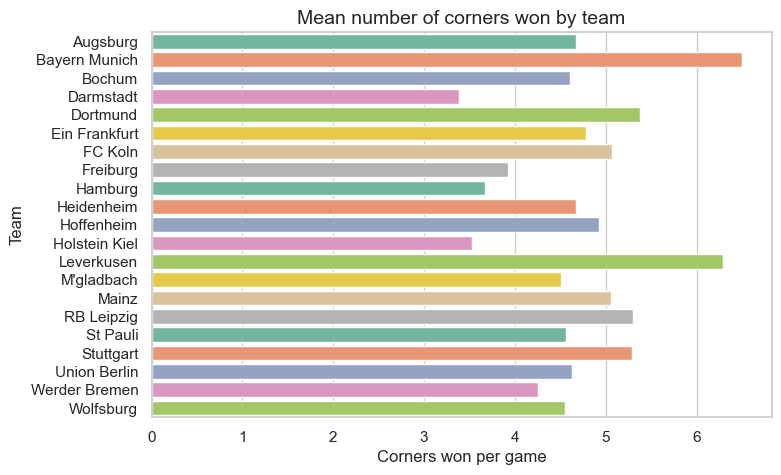

In [10]:
#we make the plot of the mean number of corners won by a team per game

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x='mean_corners', y='Team', data=teams_corners, palette='Set2')

plt.title('Mean number of corners won by team', fontsize=14)
plt.xlabel('Corners won per game')
plt.ylabel('Team')

plt.show()

C:\Users\tilen\AppData\Local\Temp\ipykernel_26908\1388474289.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_goals', y='Team', data=teams_goals, palette='Set2')


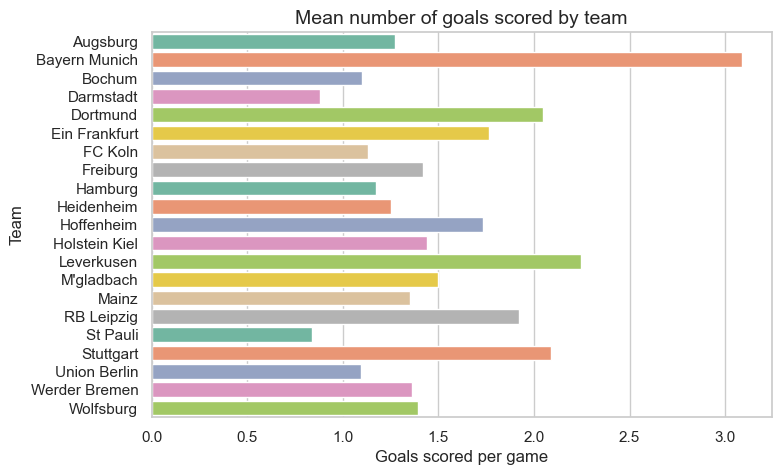

C:\Users\tilen\AppData\Local\Temp\ipykernel_26908\1388474289.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_htgoals', y='Team', data=teams_goals, palette='Set2')


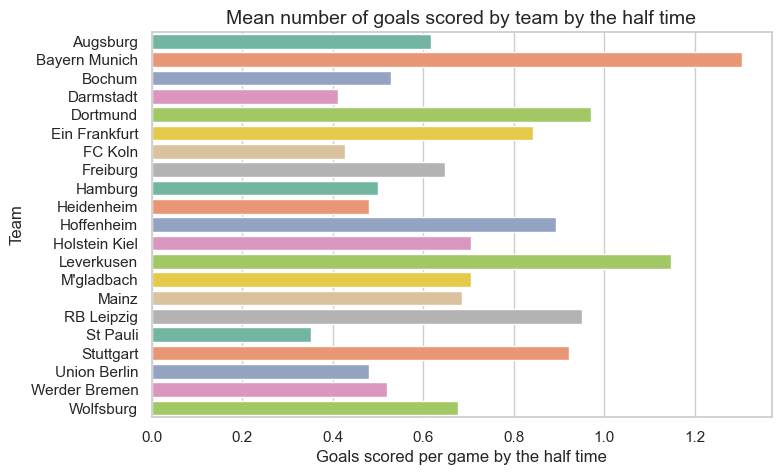

In [11]:
#we make the plot of the mean number of goals scored by a team per game

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x='mean_goals', y='Team', data=teams_goals, palette='Set2')

plt.title('Mean number of goals scored by team', fontsize=14)
plt.xlabel('Goals scored per game')
plt.ylabel('Team')

plt.show()


#we make the plot of the mean number of goals scored by a team per game by the half time

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x='mean_htgoals', y='Team', data=teams_goals, palette='Set2')

plt.title('Mean number of goals scored by team by the half time', fontsize=14)
plt.xlabel('Goals scored per game by the half time')
plt.ylabel('Team')

plt.show()

In [12]:
#here we compute the mean number of shoots made by a team in a game
#and the mean number of shoots on target

teams_shoots = pd.merge(Total_Shoots_stats, Total_Games_stats, on='Team', how='outer')


teams_shoots['mean_shoots'] = teams_shoots['TotalShoots'] / teams_shoots['Total_Games'] 
teams_shoots['mean_shoots_ontarget'] = teams_shoots['TotalShootsTarget'] / teams_shoots['Total_Games'] 

teams_shoots


,Team,HomeShoots,AwayShoots,TotalShoots,HomeShootsTarget,AwayShootsTarget,TotalShootsTarget,HomeGames,AwayGames,Total_Games,mean_shoots,mean_shoots_ontarget
0,Augsburg,682.0,595.0,1277.0,237.0,182.0,419.0,51,51,102,12.519608,4.107843
1,Bayern Munich,1062.0,857.0,1919.0,444.0,363.0,807.0,51,51,102,18.813725,7.911765
2,Bochum,542.0,385.0,927.0,174.0,126.0,300.0,34,34,68,13.632353,4.411765
3,Darmstadt,218.0,184.0,402.0,71.0,45.0,116.0,17,17,34,11.823529,3.411765
4,Dortmund,802.0,617.0,1419.0,295.0,225.0,520.0,51,51,102,13.911765,5.098039
5,Ein Frankfurt,731.0,549.0,1280.0,274.0,215.0,489.0,51,51,102,12.549020,4.794118
6,FC Koln,503.0,379.0,882.0,172.0,135.0,307.0,34,34,68,12.970588,4.514706
7,Freiburg,698.0,517.0,1215.0,244.0,185.0,429.0,51,51,102,11.911765,4.205882
8,Hamburg,226.0,192.0,418.0,80.0,75.0,155.0,17,17,34,12.294118,4.558824
9,Heidenheim,645.0,536.0,1181.0,207.0,169.0,376.0,51,51,102,11.578431,3.686275


C:\Users\tilen\AppData\Local\Temp\ipykernel_26908\363981750.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_shoots', y='Team', data=teams_shoots, palette='Set2')


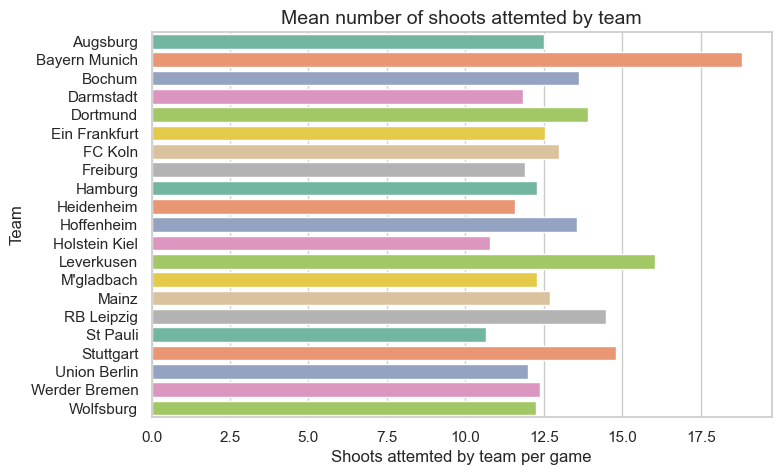

C:\Users\tilen\AppData\Local\Temp\ipykernel_26908\363981750.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_shoots_ontarget', y='Team', data=teams_shoots, palette='Set2')


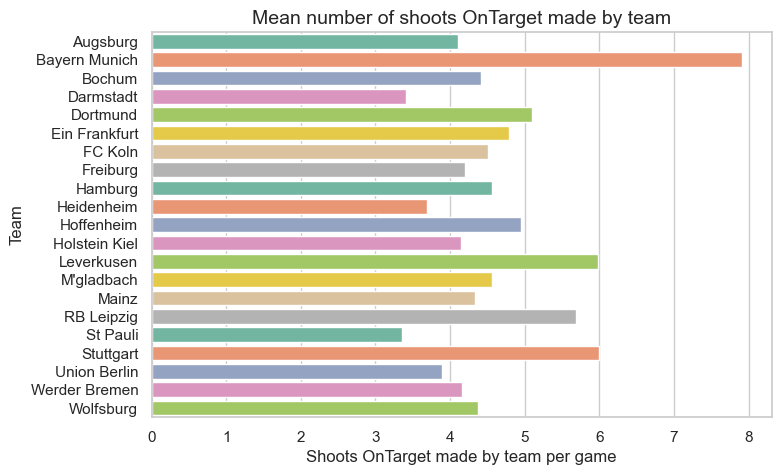

In [13]:
#we make the plot of shoots attemted by a team per game

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x='mean_shoots', y='Team', data=teams_shoots, palette='Set2')

plt.title('Mean number of shoots attemted by team', fontsize=14)
plt.xlabel('Shoots attemted by team per game')
plt.ylabel('Team')

plt.show()



#we make the plot of shoots on target made by a team per game

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x='mean_shoots_ontarget', y='Team', data=teams_shoots, palette='Set2')

plt.title('Mean number of shoots OnTarget made by team', fontsize=14)
plt.xlabel('Shoots OnTarget made by team per game')
plt.ylabel('Team')

plt.show()

In [14]:
#here we run the regression for the corners and the goals
#the regression will show us how the corners are related
#to the goals scored by each team 

X = teams_corners['TotalCorners']
Y = teams_goals['Total_Goals']

# Statsmodels needs you to manually add a constant (intercept) to the X data
X = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(Y, X).fit()

# Print the full statistical summary
print(model.summary())



######################################regression result explained######################################

# 1)For each 1 corner more won by a team through the season, total goals of this team are expected to be +0.4139(1 goals for 2.5 corners won)   
# 2)The result is statistically significant, as the P>|t| is <0.05
# 3)The relationship betweent the goals scored by a team and the corners won is extremely strong for footbal standards
##  as can be seen by the value of R-Squared which is 0.821


#########################mathematical relationship############################

#              Total_Goals = (0.4139 * Total_Corners) - 36.7369

                            OLS Regression Results                            
Dep. Variable:            Total_Goals   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     87.07
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           1.59e-08
Time:                        12:21:07   Log-Likelihood:                -100.81
No. Observations:                  21   AIC:                             205.6
Df Residuals:                      19   BIC:                             207.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -36.7369     20.078     -1.830   

In [15]:
#here we run the regression for the total shoots and the goals
#the regression will show us how the total shoots are related
#to the goals scored by each team 

X = Total_Shoots_stats['TotalShoots']
Y = teams_goals['Total_Goals']

# Statsmodels needs you to manually add a constant (intercept) to the X data
X = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(Y, X).fit()

# Print the full statistical summary
print(model.summary())


######################################regression result explained######################################

# 1)For each 1 shoot made by a team through the season, total goals of this team are expected to be +0.1656(1 goal every 6 shoots attemted)   
# 2)The result is statistically significant, as the P>|t| is <0.05
# 3)The relationship betweent the goals scored by a team and shoots made is extremely strong 
##  as can be seen by the value of R-Squared which is 0.891
# 4) Durbin-Watson value is close to 2, which shows that there is no particular correlation problem

#########################mathematical relationship############################

#              Total_Goals = (0.1656 * Total_Shoots) - 51.8718

                            OLS Regression Results                            
Dep. Variable:            Total_Goals   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     155.3
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           1.37e-10
Time:                        12:21:07   Log-Likelihood:                -95.596
No. Observations:                  21   AIC:                             195.2
Df Residuals:                      19   BIC:                             197.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -51.8718     16.252     -3.192      

In [16]:
#here we run the regression for the shoots on target and the goals
#the regression will show us how the shoots on target are related
#to the goals scored by each team 

X = Total_Shoots_stats['TotalShootsTarget']
Y = teams_goals['Total_Goals']

# Statsmodels needs you to manually add a constant (intercept) to the X data
X = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(Y, X).fit()

# Print the full statistical summary
print(model.summary())


######################################regression result explained######################################

# 1)For each 1 shoot on target made by a team through the season, total goals of this team are expected to be +0.4108(1 goal every 6 shoots attemted)   
# 2)The result is statistically significant, as the P>|t| is <0.05
# 3)The relationship betweent the goals scored by a team and shoots made is extremely strong 
##  as can be seen by the value of R-Squared which is 0.965
# 4) Durbin-Watson value remains close to 2, which shows that there is no particular correlation problem

#########################mathematical relationship############################

#              Total_Goals = (0.4108 * Total_Shoots_onTarget) - 31.8123

                            OLS Regression Results                            
Dep. Variable:            Total_Goals   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     528.6
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           2.49e-15
Time:                        12:21:07   Log-Likelihood:                -83.573
No. Observations:                  21   AIC:                             171.1
Df Residuals:                      19   BIC:                             173.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -31.8123      8.03